# Homework 7

## Author: Pablo Leyva

### HW7: Principal Component Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate noisy data from y = cx
c = 2.5  # scalar coefficient
n_points = 50
x = np.linspace(0, 10, n_points)
y_true = c * x
noise = np.random.normal(0, 1, n_points)  # Gaussian noise
y_noisy = y_true + noise

print(f"Original data: {n_points} points")
print(f"True coefficient c = {c}")


Original data: 50 points
True coefficient c = 2.5


In [ ]:

A = np.vstack([x, np.ones(len(x))]).T
m, b = np.linalg.lstsq(A, y_noisy, rcond=None)[0]

print(f"Fitted line: y = {m:.4f}x + {b:.4f}")
print(f"True coefficient was: c = {c}")


Fitted line: y = 2.4420x + 0.0644
True coefficient was: c = 2.5


In [ ]:

y_pred = m * x + b
y_mean = np.mean(y_noisy)

# Sum of squared residuals (vertical distances)
SS_res = np.sum((y_noisy - y_pred)**2)

# Total sum of squares
SS_tot = np.sum((y_noisy - y_mean)**2)

# Coefficient of determination
r2 = 1 - (SS_res / SS_tot)

print(f"Sum of squared residuals (SS_res): {SS_res:.4f}")
print(f"Total sum of squares (SS_tot): {SS_tot:.4f}")
print(f"r² (coefficient of determination): {r2:.4f}")


Sum of squared residuals (SS_res): 41.2571
Total sum of squares (SS_tot): 2627.4450
r² (coefficient of determination): 0.9843


In [4]:
# Add an outlier to the data
x_with_outlier = np.append(x, 8.0)
y_with_outlier = np.append(y_noisy, 30.0)  # Large outlier value

print(f"Data with outlier: {len(x_with_outlier)} points")
print(f"Outlier point: x={8.0}, y={30.0}")


Data with outlier: 51 points
Outlier point: x=8.0, y=30.0


In [5]:
# Least-squares fit to data with outlier
A_outlier = np.vstack([x_with_outlier, np.ones(len(x_with_outlier))]).T
m_outlier, b_outlier = np.linalg.lstsq(A_outlier, y_with_outlier, rcond=None)[0]

print(f"Fitted line with outlier: y = {m_outlier:.4f}x + {b_outlier:.4f}")
print(f"Original fit: y = {m:.4f}x + {b:.4f}")


Fitted line with outlier: y = 2.5111x + -0.0813
Original fit: y = 2.4420x + 0.0644


In [6]:
# Compute r² for fit with outlier
y_pred_outlier = m_outlier * x_with_outlier + b_outlier
y_mean_outlier = np.mean(y_with_outlier)

SS_res_outlier = np.sum((y_with_outlier - y_pred_outlier)**2)
SS_tot_outlier = np.sum((y_with_outlier - y_mean_outlier)**2)
r2_outlier = 1 - (SS_res_outlier / SS_tot_outlier)

print(f"Sum of squared residuals (SS_res) with outlier: {SS_res_outlier:.4f}")
print(f"Total sum of squares (SS_tot) with outlier: {SS_tot_outlier:.4f}")
print(f"r² (coefficient of determination) with outlier: {r2_outlier:.4f}")
print(f"\nChange in r²: {r2_outlier - r2:.4f}")


Sum of squared residuals (SS_res) with outlier: 145.1703
Total sum of squares (SS_tot) with outlier: 2935.4768
r² (coefficient of determination) with outlier: 0.9505

Change in r²: -0.0338


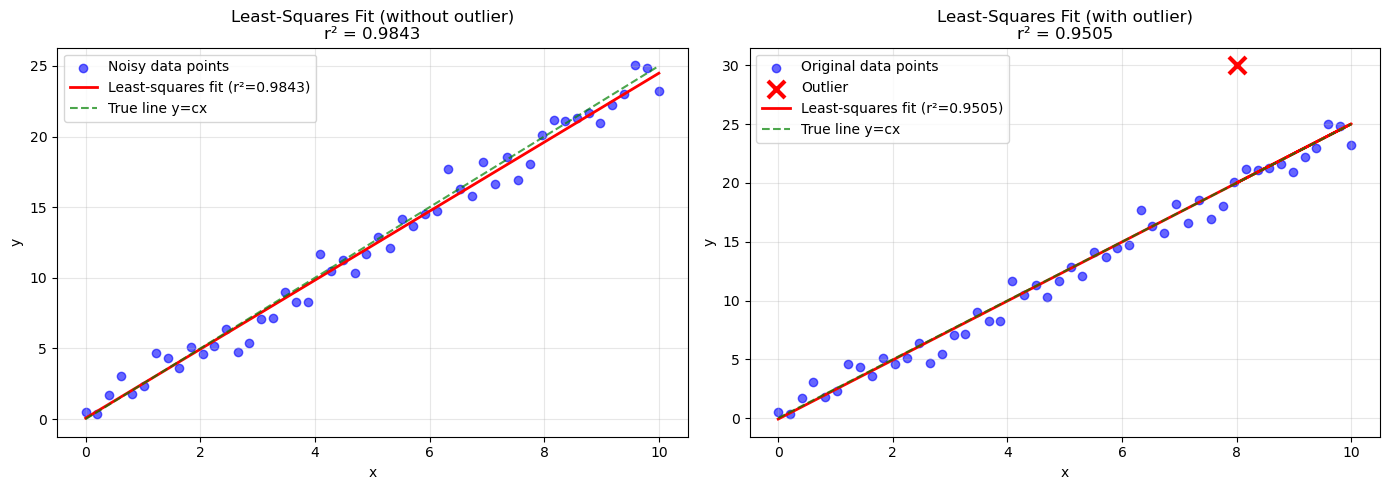

In [7]:
# Plot both fits alongside the data points
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original data without outlier
ax1.scatter(x, y_noisy, alpha=0.6, label='Noisy data points', color='blue')
ax1.plot(x, y_pred, 'r-', linewidth=2, label=f'Least-squares fit (r²={r2:.4f})')
ax1.plot(x, y_true, 'g--', linewidth=1.5, alpha=0.7, label='True line y=cx')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(f'Least-Squares Fit (without outlier)\nr² = {r2:.4f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Data with outlier
ax2.scatter(x, y_noisy, alpha=0.6, label='Original data points', color='blue')
ax2.scatter(8.0, 30.0, s=150, color='red', marker='x', linewidths=3, label='Outlier', zorder=5)
ax2.plot(x_with_outlier, y_pred_outlier, 'r-', linewidth=2, label=f'Least-squares fit (r²={r2_outlier:.4f})')
ax2.plot(x, y_true, 'g--', linewidth=1.5, alpha=0.7, label='True line y=cx')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title(f'Least-Squares Fit (with outlier)\nr² = {r2_outlier:.4f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Analysis and Comments on Fit Quality

**Original Fit (without outlier):**
- The r² value indicates the strength of the relationship between x and y.
- Values close to 1 indicate a strong linear relationship, while values close to 0 suggest a weak relationship.
- The least-squares fit should closely follow the true relationship y = cx, with small residuals relative to the total variation in the data.

**Fit with Outlier:**
- The r² value typically decreases when an outlier is added, indicating a weaker relationship.
- The outlier significantly affects the least-squares fit, pulling the line away from the true relationship.
- This demonstrates the sensitivity of least-squares regression to outliers, as the method minimizes the sum of squared residuals, giving outliers high influence.

**Key Observations:**
1. **Least-squares sensitivity**: Least-squares regression is highly sensitive to outliers - a single outlier can significantly degrade the fit quality and bias the estimated coefficients.
2. **r² interpretation**: The coefficient of determination (r²) is a useful measure of fit quality:
   - r² ≈ 1: Excellent fit, model explains most of the variance
   - r² ≈ 0: Poor fit, model explains little variance
   - Negative r²: Model performs worse than simply predicting the mean
3. **Robust alternatives**: When outliers are present, robust regression methods (like RANSAC, Huber regression, or L1 regression) might be more appropriate as they are less sensitive to outliers.
